# Part 1
The following code reads a subset of image data of handwritten digits. The data matrix `X` contains the images: each row is an 8x8 image. The vector `y` contains the true digit for each image. In ML, we call `y` the labels/targets (or “étiquettes” en français).


La taille des données est (1797, 64) et celle des labels est (1797,)
La première image ressemble à:


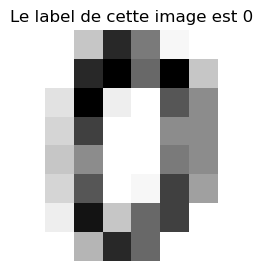

In [4]:
import numpy as np
from sklearn.datasets import load_digits
from matplotlib import pyplot as plt

digits = load_digits()
X = digits.data
y = digits.target

print(f"La taille des données est {X.shape} et celle des labels est {y.shape}")
print(f"La première image ressemble à:")
plt.figure(figsize=(3, 3))
plt.imshow(X[0].reshape(8, 8), cmap="Greys")
plt.axis("off")
plt.title(f"Le label de cette image est {y[0]}")
plt.show()

### Question 1
Visualize the first 8 images of the dataset in a single figure, with their true label shown as the title for each image.


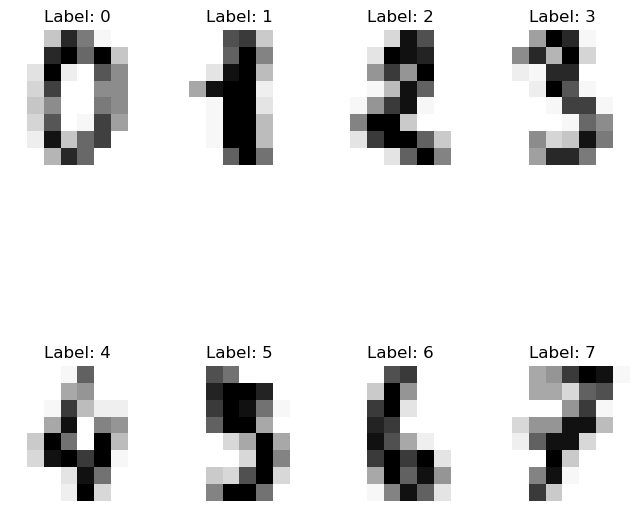

In [5]:
#visuaalisation des 8 premières images sur une meme figure
plt.figure(figsize=(8, 8))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(X[i].reshape(8, 8), cmap="Greys")
    plt.axis("off")
    plt.title(f"Label: {y[i]}")

### Question 2
Prepare the data to perform a principal component analysis and compute the covariance matrix.


In [6]:
#Preparation des données pour L'ACP
X_centered = X - np.mean(X, axis=0)
#Calcul de la matrice de covariance
cov_matrix = np.cov(X_centered, rowvar=False)

### Question 3
Determine the principal axes and their variances, then visualize the 2-dimensional projection using a `plt.scatter`, including the percentage of variance explained by each principal axis. 


Text(0.5, 1.0, 'Projection des données sur les deux premiers axes principaux')

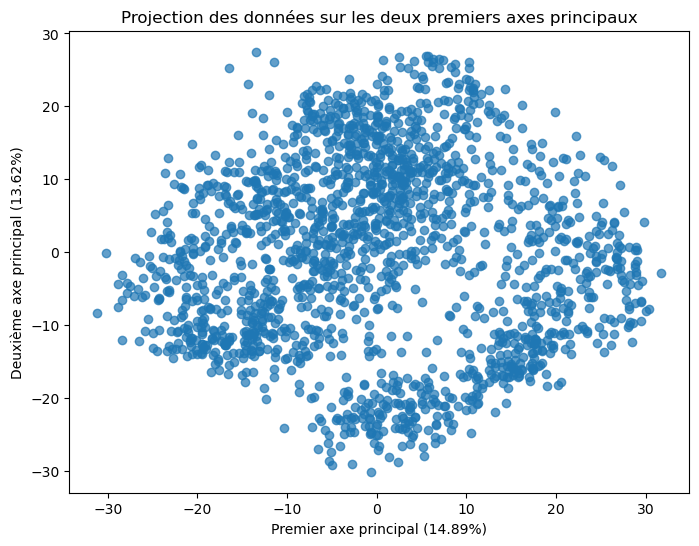

In [7]:
#Derermination  des axes principaux via la diagonalisation de la matrice de covariance
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
#Tri des valeurs propres et des vecteurs propres associés
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]
#Projection des données sur les deux premiers axes principaux
X_pca = X_centered.dot(eigenvectors[:, :2])
#Visualisation des données projetées avec scatter plot
p1=eigenvalues[0]/np.sum(eigenvalues)*100
p2=eigenvalues[1]/np.sum(eigenvalues)*100
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7)
plt.xlabel(f"Premier axe principal ({p1:.2f}%)")
plt.ylabel(f"Deuxième axe principal ({p2:.2f}%)")
plt.title("Projection des données sur les deux premiers axes principaux")

### Question 4
In the 2D projection figure, color each point according to its true label to see whether PCA made it possible to separate the digits into separate clusters. 

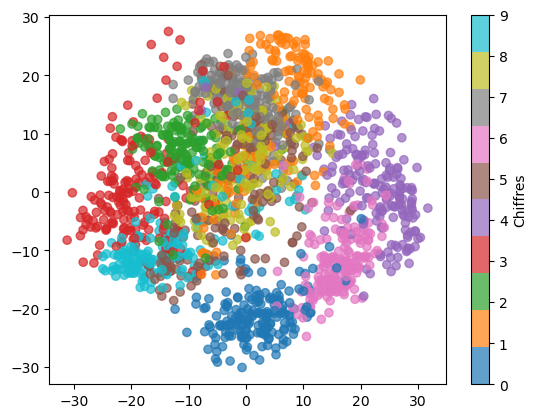

In [8]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', alpha=0.7)
plt.colorbar(ticks=range(10), label='Chiffres')


We  remark that PCA doesn't make possible to split the digit in differents clusters

### Question 5
Visualize the scree plot (the curve of the cumulative percentage of explained variance as a function of the principal component index, in decreasing order of importance) for this PCA. 

Text(0.5, 1.0, 'scree plot')

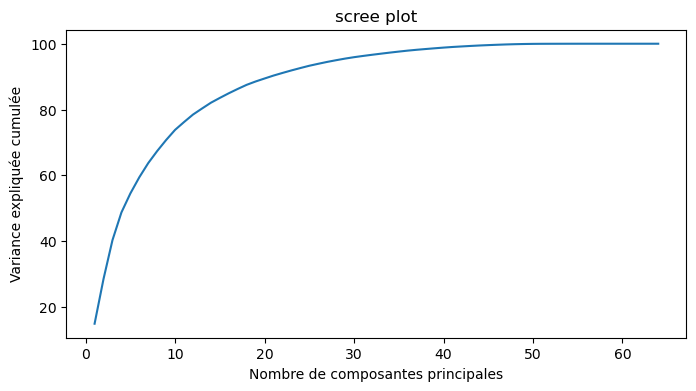

In [9]:
#Visualisation de la variance culmulée
explained_variance = np.cumsum(eigenvalues) / np.sum(eigenvalues)*100
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(explained_variance) + 1), explained_variance)
plt.xlabel('Nombre de composantes principales')
plt.ylabel('Variance expliquée cumulée')
plt.title("scree plot")

# Part 2: Non-linear methods

In [10]:
from sklearn.manifold import  TSNE

### Question 9:
Run TSNE and play around with `perplexity`. Check the [TSNE documentation](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html)

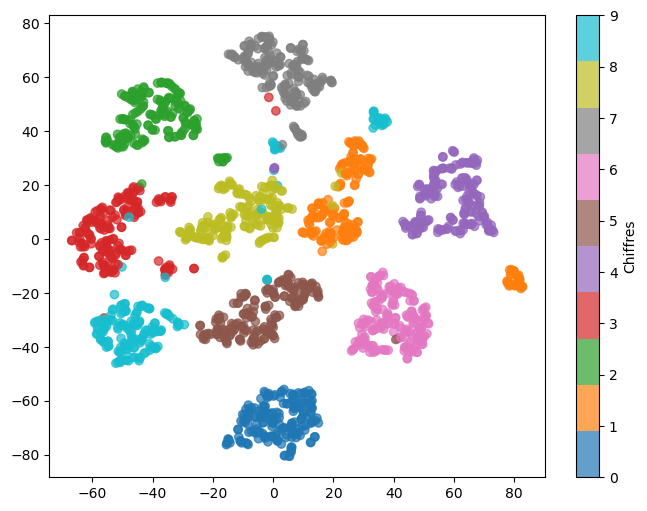

In [11]:
#implementation de t-SNE
tsne = TSNE(n_components=2, perplexity=10)
X_tsne = tsne.fit_transform(X)
plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='tab10', alpha=0.7)
plt.colorbar(ticks=range(10), label='Chiffres')

# Part 3: SVHN dataset
Now we move on to a more complex dataset: the SVHN (Street view house numbers). You can download it here:

In [12]:
import os, requests
import numpy as np
url = "https://www.dropbox.com/scl/fi/5u0s8hdv7wyzh8rhndi2o/small_svhn.npz?rlkey=l0zsmchiymz8qmdjb16koijqa&dl=1"

local_path = "small_svhn.npz"

if not os.path.exists(local_path):
    print("Downloading small_svhn.npz...")
    with requests.get(url, stream=True) as r:
        r.raise_for_status()
        with open(local_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=8192):
                if chunk:
                    f.write(chunk)
else:
    print("Using cached small_svhn.npz")

data = np.load(local_path)

X = np.load("small_svhn.npz")["X"]
y = np.load("small_svhn.npz")["y"]

print(f"The shape of the dataset is {X.shape}")
print(f"The first labels are {y[:10]}")

Using cached small_svhn.npz
The shape of the dataset is (3662, 32, 32)
The first labels are [1 1 0 2 6 4 2 5 9 0]


### Question 11: 
Visualize the first images and their labels. What do you notice ?

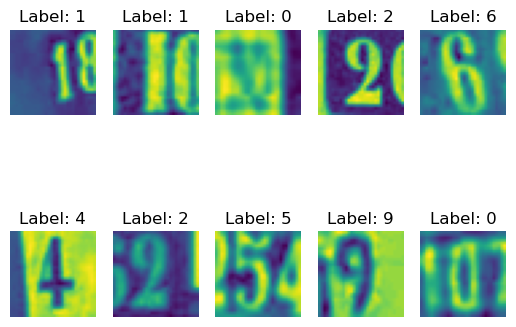

In [13]:
#Visualisation des premières images du dataset SVHN
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X[i].reshape(32, 32))
    plt.axis("off")
    plt.title(f"Label: {y[i]}")

### Question 12:
Apply PCA and  t-SNE  on the dataset

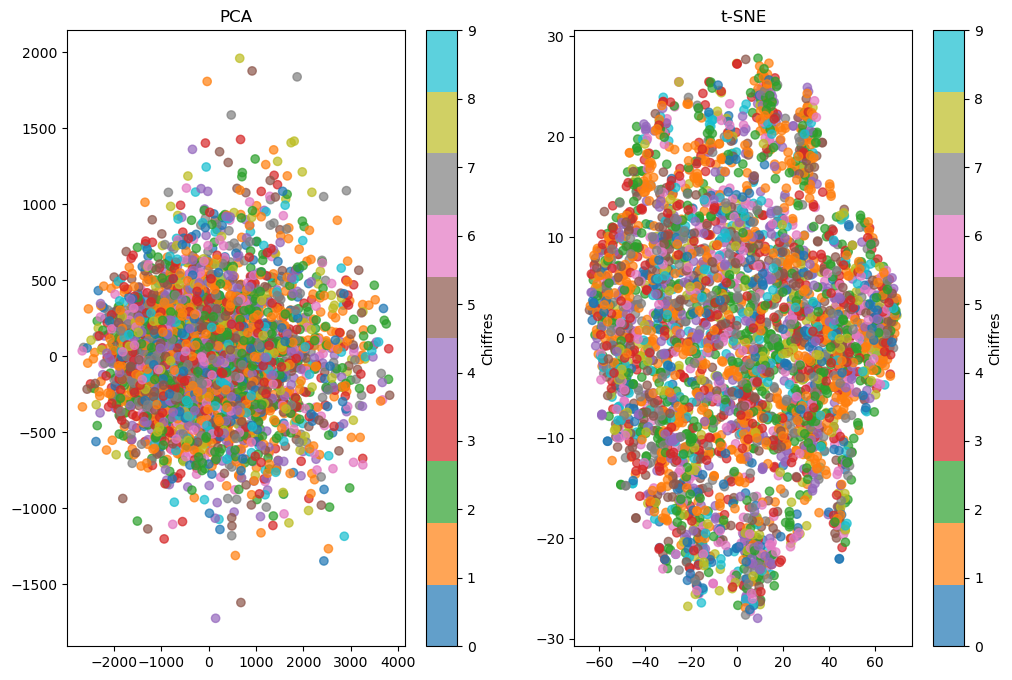

In [15]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.reshape(3662,32*32))
tsne = TSNE(n_components=2, perplexity=30)
X_tsne = tsne.fit_transform(X.reshape(3662,32*32))
plt.figure(figsize=( 12, 8)) 

# PCA
plt.subplot(1, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', alpha=0.7)
plt.colorbar(ticks=range(10), label='Chiffres')
plt.title("PCA")

# t-SNE
plt.subplot(1, 2, 2)
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='tab10', alpha=0.7)
plt.colorbar(ticks=range(10), label='Chiffres')
plt.title("t-SNE")  



plt.show()

# On a pas reussi à separer les différentes classes avec PCA, t-SNE et UMAP sur ce dataset SVHN.


# Challenge
Les images SVHN ont une très grande variabilité ce qui rend la séparation des clusters difficile. Le défi est de chercher (une ou des transformations) à appliquer à ces images afin d'extraire des "features" qui simplifient la tâche de t-SNE. Par exemple, on peut jouer sur le contraste, les filtres, la taille des images etc. On note la transformation appliquée à ces images par $\phi$:
$$ \phi: \quad image \in \mathbb R^{32 \times 32} \mapsto \phi(image) \in \mathbb R^{k} $$ 

à vous de définir la transformation $\phi$ adéquate telle que t-SNE appliquée sur $\phi(images)$ distingue au mieux les clusters. Pour définir la transformation $\phi$ vous pouvez utiliser n'importe quelle librairie Python à condition de respecter les règles suivantes:
- $\phi$ ne dépend que des images $X$ et n'utilise pas les labels $y$
- Comprendre exactement ce que fait la fonction $\phi$ 

Pour vous expliquer l'évaluation de votre rendu, on commence avec une fonction $\phi$ naive qui ne fait que reshape chaque image 32 x 32 en un vecteur de taille 1024. On utilise la fonction `transform_images` qui calcule $phi(x_i)$ pour chaque image $x_i$ et renvoie le dataset transformé en dimension $k$:

In [22]:
from skimage.feature import hog
from sklearn.decomposition import PCA
import numpy as np
# Option 1 : HOG seul (dimensions ~300-800 selon paramètres)
def phi(image):
    gray = image.copy()
    fd = hog(gray, orientations=9, pixels_per_cell=(4,4),   
             cells_per_block=(2,2), block_norm='L2-Hys',
             feature_vector=True)
    return fd  

def transform_images(X):
    out = []
    for image in X:
        phi_x = phi(image)
        out.append(phi_x)
    return np.array(out)

In [24]:
from time import time

t0 = time()
X_transformed = transform_images(X)
t1 = time()

print(f"Temps pris pour la transformation du dataset: {t1 - t0}s | Nouvelle dimension des données: {X_transformed.shape}")


Temps pris pour la transformation du dataset: 9.65884280204773s | Nouvelle dimension des données: (3662, 1764)


On applique t_SNE sur ces données transformées. Afin de garder la reproducibilité du code et de pouvoir comparer avec les autres soumissions de façon équitable, on ajoute random_state=42

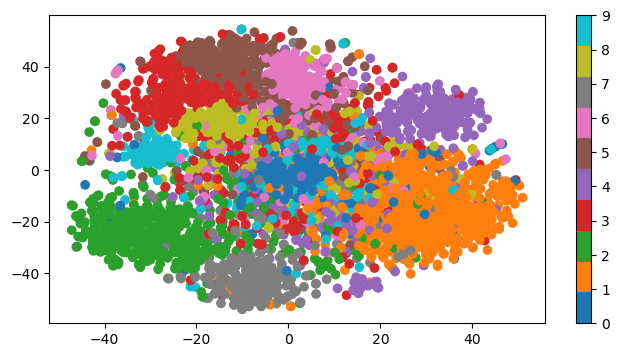

In [25]:
from sklearn.manifold import TSNE
from matplotlib import pyplot as plt
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_transformed)


plt.figure(figsize=(8, 4))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap="tab10")
plt.colorbar()
plt.show()

Pour évaluer la qualité des clusters, on évalue simplement la performance d'un k-NN sur la représentation t-SNE. 

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

X_train, X_test, y_train, y_test = train_test_split(X_tsne, y, test_size=0.2, random_state=42, stratify=y)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

score = knn.score(X_test, y_test)
print(f"Score du k-NN: {score}")

Score du k-NN: 0.7312414733969986
